## Navigo KO: GLI DEG Enrichment Summary

This tutorial summarizes and visualizes the directionality of DEG enrichment following Gli1/Gli3 knockout across developmental lineages.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

## Configuration

In [2]:
DATA_DIR       = Path("/scratch/users/steorra/analysis/26_yimin/data")
CHECKPOINT_DIR = Path("/scratch/users/steorra/analysis/26_yimin/checkpoints")
OUTPUT_DIR     = Path("/scratch/users/steorra/analysis/26_yimin/Navigo-release/docs/tutorials/outputs")

data_root = DATA_DIR / 'knockout'
case_output_root = OUTPUT_DIR / 'knockout_gli_deg_enrichment_summary'
TABLE_DIR = case_output_root / '01_tables'
FIG_DIR   = case_output_root / '02_figures'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

CATEGORY_TABLES = {
    'gli1': data_root / 'gene_compensation' / 'gli_output' / 'deg_enrichment_gli1.csv',
    'gli3': data_root / 'gene_compensation' / 'gli_output' / 'deg_enrichment_gli3.csv',
    'gli1_gli3': data_root / 'gene_compensation' / 'gli_output' / 'deg_enrichment_gli1_gli3.csv',
    'gli1_gli3_combined': data_root / 'gene_compensation' / 'gli_output' / 'deg_enrichment_gli1_gli3_combined.csv',
}

## Step 1: Build category overview

In [3]:
rows = [{'category': k, 'num_rows': len(pd.read_csv(v)),
         'min_same_p': float(pd.read_csv(v)['same_p_value'].min()),
         'min_opposite_p': float(pd.read_csv(v)['opposite_p_value'].min())}
        for k, v in CATEGORY_TABLES.items()]
overview = pd.DataFrame(rows).sort_values('category').reset_index(drop=True)
overview.to_csv(TABLE_DIR / '01_deg_enrichment_category_overview.csv', index=False)
overview

,category,num_rows,min_same_p,min_opposite_p
0,gli1,6,3.872642e-06,0.941806
1,gli1_gli3,6,1.871123e-06,0.701700
2,gli1_gli3_combined,6,1.254366e-05,0.975739
3,gli3,6,3.447199e-07,0.008636


## Step 2: Prepare plot table

In [4]:
plot_order = ['Limb_mesenchyme_trajectory', 'Chondrocyte_trajectory', 'Intermediate_mesoderm_trajectory',
              'Motor_neuron_trajectory', 'Spinal_cord_dorsal_trajectory', 'Osteoblast_trajectory']
plot_labels = ['Limb mesenchyme', 'Chondrocyte', 'Intermediate mesoderm',
               'Motor neuron', 'Spinal cord dorsal', 'Osteoblast']

df = pd.read_csv(CATEGORY_TABLES['gli1_gli3_combined']).set_index('cell_type').loc[plot_order].reset_index()
df['label'] = plot_labels
df['same_neglog10p']      = -np.log10(df['same_p_value'].clip(lower=1e-300))
df['different_neglog10p'] = -np.log10(df['opposite_p_value'].clip(lower=1e-300))
plot_table = df[['cell_type', 'label', 'same_p_value', 'opposite_p_value', 'same_neglog10p', 'different_neglog10p']]
plot_table.to_csv(TABLE_DIR / '01_gli1_gli3_combined_plot_table.csv', index=False)
plot_table

,cell_type,label,same_p_value,opposite_p_value,same_neglog10p,different_neglog10p
0,Limb_mesenchyme_trajectory,Limb mesenchyme,0.021974,0.983518,1.658081,0.007218
1,Chondrocyte_trajectory,Chondrocyte,0.038807,0.975739,1.411091,0.010666
2,Intermediate_mesoderm_trajectory,Intermediate mesoderm,0.031062,0.977363,1.507769,0.009944
3,Motor_neuron_trajectory,Motor neuron,0.000018,0.999991,4.738028,0.000004
4,Spinal_cord_dorsal_trajectory,Spinal cord dorsal,0.000013,0.999996,4.901576,0.000002
5,Osteoblast_trajectory,Osteoblast,0.001739,0.999179,2.759713,0.000357


## Step 3: Visualize DEG enrichment directionality

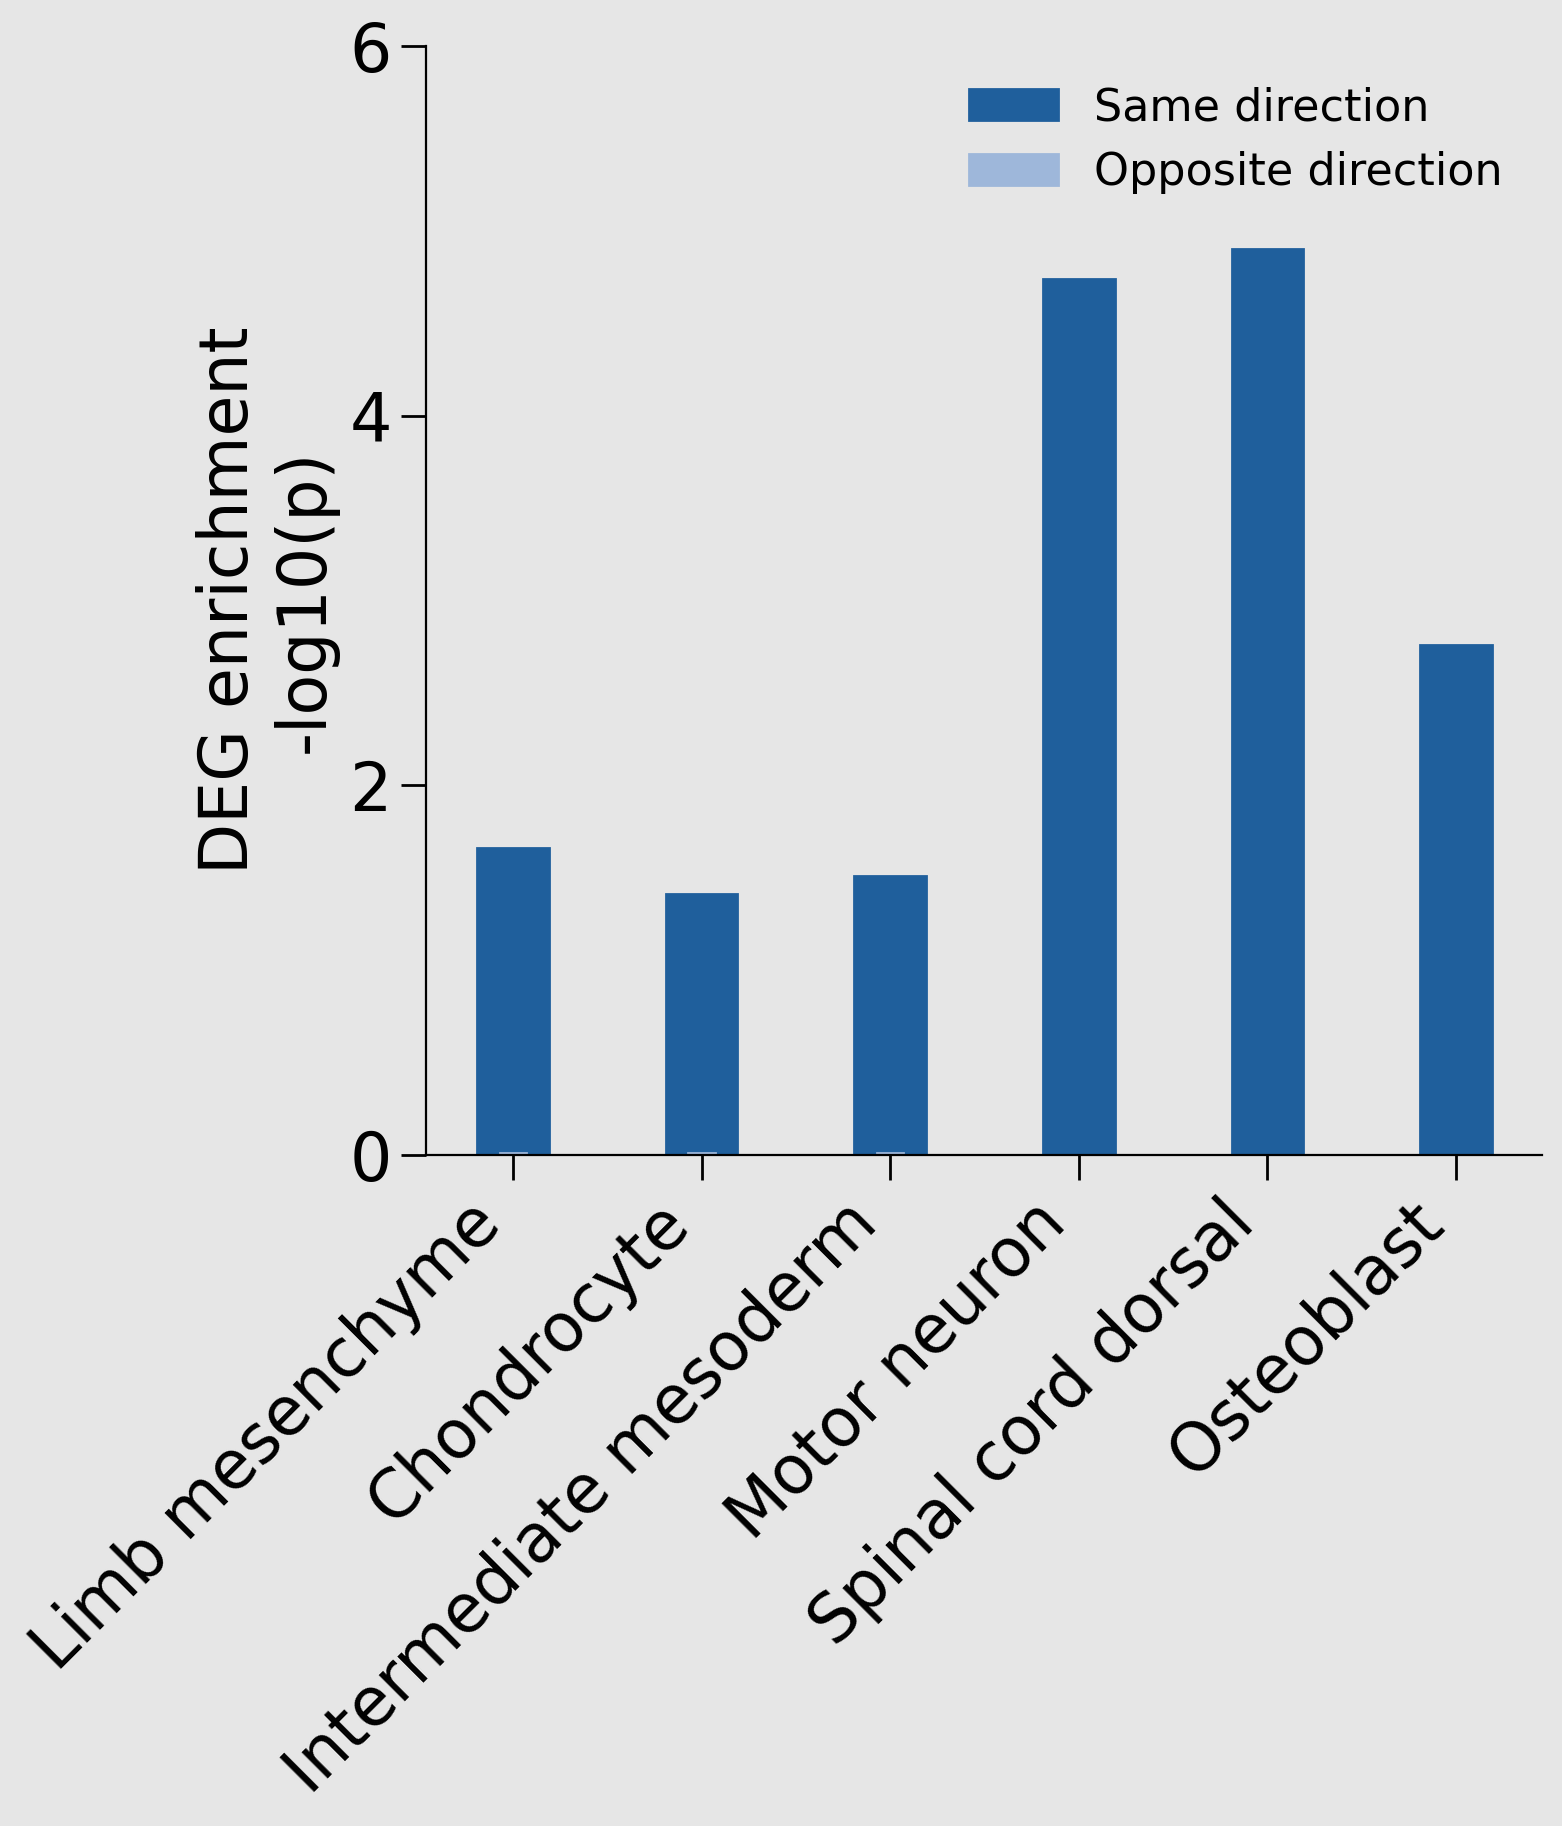

In [5]:
x = np.arange(len(plot_table))
fig, ax = plt.subplots(figsize=(7.2, 7.2), facecolor='#e6e6e6')
ax.set_facecolor('#e6e6e6')
ax.bar(x, plot_table['same_neglog10p'], width=0.38, color='#1f5f9c', edgecolor='#1f5f9c', label='Same direction')
ax.bar(x, plot_table['different_neglog10p'], width=0.14, color='#9eb7da', edgecolor='#9eb7da', label='Opposite direction')
ax.set_xticks(x)
ax.set_xticklabels(plot_table['label'], rotation=45, ha='right', fontsize=20)
ax.set_ylabel('DEG enrichment\n-log10(p)', fontsize=24)
ax.set_ylim(0, 6.0); ax.set_yticks([0, 2, 4, 6])
ax.tick_params(axis='both', labelsize=24, width=1.0, length=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=16, loc='upper right')
fig.savefig(FIG_DIR / '01_gli1_gli3_combined_deg_enrichment_barplot.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()